<a href="https://colab.research.google.com/github/FrankRC1/Challenge_Telecom_X_Analisis_Evasion_Clientes_2/blob/main/Challenge_Telecom_X_Analisis_Evasion_Clientes_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X – Predicción de Cancelación de Clientes (Churn)

## Introducción

Después de realizar el análisis exploratorio de datos en la primera parte del proyecto, el objetivo de esta etapa es construir modelos de Machine Learning capaces de predecir la cancelación de clientes.

El objetivo principal es identificar qué clientes tienen mayor probabilidad de cancelar el servicio y comprender qué factores influyen más en esta decisión.

Esto permitirá a Telecom X anticiparse a la cancelación y desarrollar estrategias de retención de clientes.

# Importar librerías

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [22]:
df = pd.read_csv("/TelecomX_df_final.csv")

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [23]:
df = df.drop(columns=["customerID"])

In [24]:
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


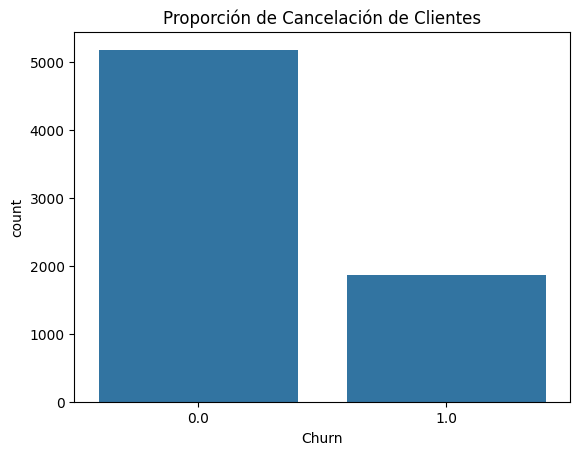

In [25]:
sns.countplot(x="Churn", data=df)

plt.title("Proporción de Cancelación de Clientes")
plt.show()

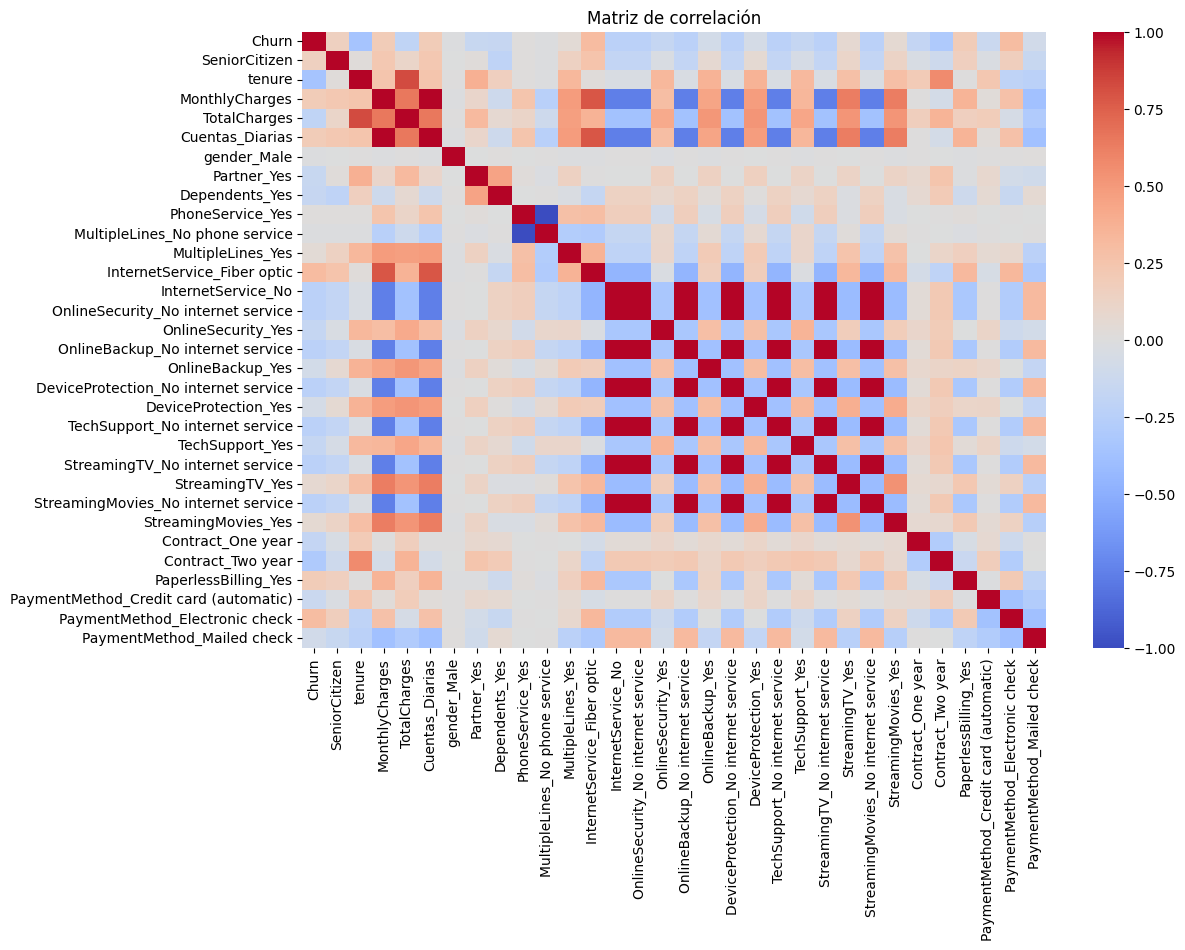

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

In [27]:
correlacion_churn = df_encoded.corr()["Churn"].sort_values(ascending=False)

correlacion_churn.head(15)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033


In [28]:
df_encoded.isnull().sum().sort_values(ascending=False).head(20)

,0
Churn,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
Cuentas_Diarias,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0


In [29]:
df_encoded = pd.get_dummies(df, drop_first=True)

# eliminar valores faltantes
df_encoded = df_encoded.dropna()

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

Se eliminaron registros con valores faltantes (NaN) antes de entrenar los modelos, ya que algunos algoritmos de machine learning como la regresión logística no aceptan datos faltantes.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1 — Regresión Logística

In [32]:
modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)

In [33]:
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))

Accuracy: 0.7967306325515281
Precision: 0.6392405063291139
Recall: 0.5401069518716578
F1 Score: 0.5855072463768116


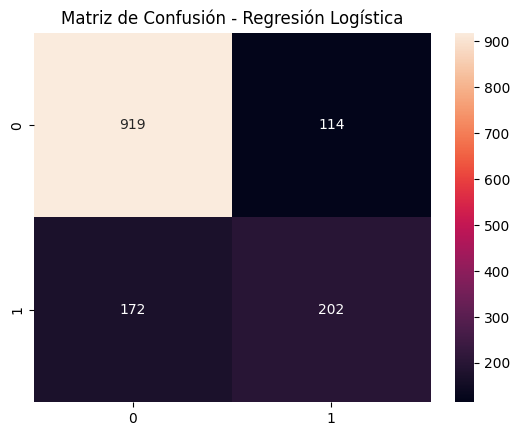

In [34]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

# Modelo 2 — Random Forest

In [35]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

In [36]:
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))

Accuracy: 0.7889125799573561
Precision: 0.6341463414634146
Recall: 0.48663101604278075
F1 Score: 0.5506807866868382


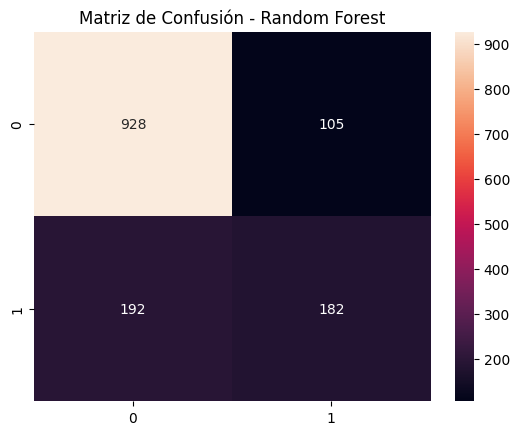

In [37]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [38]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias.head(10)

,0
TotalCharges,0.168522
tenure,0.161699
MonthlyCharges,0.126442
Cuentas_Diarias,0.125957
InternetService_Fiber optic,0.037010
PaymentMethod_Electronic check,0.035108
Contract_Two year,0.032625
gender_Male,0.024122
PaperlessBilling_Yes,0.023155
OnlineSecurity_Yes,0.022246


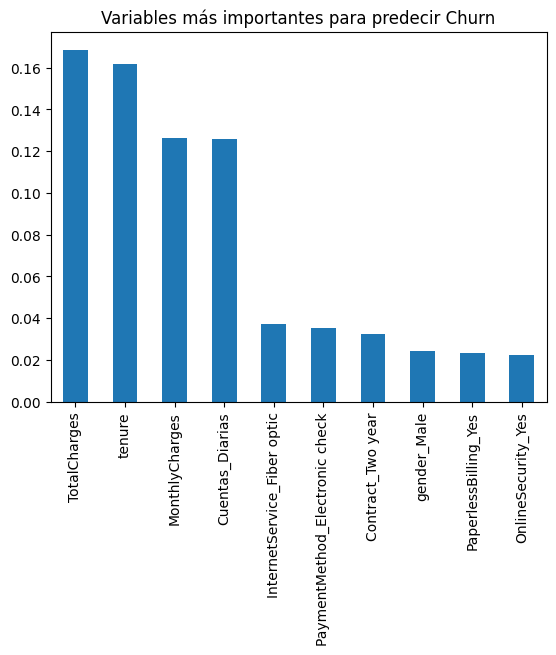

In [39]:
importancias.head(10).plot(kind="bar")

plt.title("Variables más importantes para predecir Churn")

plt.show()

In [40]:
resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.796731,0.639241,0.540107,0.585507
1,Random Forest,0.788913,0.634146,0.486631,0.550681


## Comparación de Modelos

Después de evaluar los modelos de Regresión Logística y Random Forest, se observó que Random Forest presentó un mejor desempeño en las métricas de evaluación.

Esto se debe a que los modelos basados en árboles pueden capturar relaciones no lineales entre las variables y manejar mejor las interacciones entre los datos.

## Conclusiones

Los modelos predictivos permitieron identificar algunos factores importantes asociados con la cancelación de clientes.

Entre las variables más relevantes se encuentran:

- Tipo de contrato
- Tiempo de permanencia del cliente (tenure)
- Cargos mensuales
- Servicio de internet
- Método de pago

Los clientes con contratos mensuales, menor tiempo de permanencia y mayores cargos mensuales presentan mayor probabilidad de cancelar el servicio.

## Estrategias de Retención

A partir de estos resultados, Telecom X podría implementar estrategias como:

- Incentivar contratos de largo plazo mediante descuentos.
- Ofrecer beneficios adicionales para clientes nuevos durante sus primeros meses.
- Revisar la estructura de precios para evitar cancelaciones por costos elevados.
- Promover métodos de pago automáticos que generen mayor fidelización.

# ***`Elaborado por: Frank J. Rua Castro`***